In [2]:
import os
print(os.getcwd())

/Users/mahmu/ev-digital-twin-mcp/notebooks


In [3]:
import pandas as pd

df = pd.read_csv("../data/cleaned_dataset/metadata.csv")

print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [4]:
df.columns

Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 1.3 MB


In [6]:
df["battery_id"].value_counts()

battery_id
B0006    616
B0005    616
B0007    616
B0034    486
B0033    486
B0036    486
B0018    319
B0043    275
B0042    275
B0044    275
B0054    253
B0056    252
B0055    252
B0047    184
B0045    184
B0048    184
B0046    184
B0041    163
B0053    137
B0039    122
B0040    122
B0038    122
B0032     97
B0029     97
B0030     97
B0031     97
B0028     80
B0027     80
B0025     80
B0026     80
B0049     62
B0050     62
B0052     62
B0051     62
Name: count, dtype: int64

In [7]:
capacity_df = df[df["Capacity"].notna()]

print(capacity_df.shape)

capacity_df[["battery_id", "Capacity"]].head(20)

(2794, 10)


,battery_id,Capacity
0,B0047,1.6743047446975208
4,B0047,1.5243662105099023
6,B0047,1.5080762969973425
8,B0047,1.4835577960067696
10,B0047,1.4671391666146525
12,B0047,1.448858156982267
16,B0047,1.4458534180949325
20,B0047,1.431118266178283
22,B0047,1.4192745516578533
24,B0047,1.3999974221808271


In [8]:
capacity_df.groupby("battery_id")["Capacity"].count()

battery_id
B0005    168
B0006    168
B0007    168
B0018    132
B0025     28
B0026     28
B0027     28
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    197
B0034    197
B0036    197
B0038     47
B0039     47
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0049     25
B0050     25
B0051     25
B0052     25
B0053     56
B0054    103
B0055    102
B0056    102
Name: Capacity, dtype: int64

In [10]:
capacity_df = df[df["Capacity"].notna()].copy()

capacity_df["Capacity"] = pd.to_numeric(
    capacity_df["Capacity"],
    errors="coerce"
)

capacity_df = capacity_df[capacity_df["Capacity"].notna()]
capacity_df = capacity_df[capacity_df["Capacity"] > 0]

capacity_df[["battery_id", "Capacity"]].head()

,battery_id,Capacity
0,B0047,1.674305
4,B0047,1.524366
6,B0047,1.508076
8,B0047,1.483558
10,B0047,1.467139


In [11]:
capacity_df["initial_capacity"] = (
    capacity_df.groupby("battery_id")["Capacity"]
    .transform("first")
)

capacity_df["SOH"] = (
    capacity_df["Capacity"] /
    capacity_df["initial_capacity"]
) * 100

capacity_df[["battery_id", "Capacity", "initial_capacity", "SOH"]].head()

,battery_id,Capacity,initial_capacity,SOH
0,B0047,1.674305,1.674305,100.000000
4,B0047,1.524366,1.674305,91.044729
6,B0047,1.508076,1.674305,90.071793
8,B0047,1.483558,1.674305,88.607394
10,B0047,1.467139,1.674305,87.626770


In [12]:
capacity_df["SOH"].describe()

count    2750.000000
mean      279.851861
std       551.909311
min         3.268075
25%        80.572394
50%        98.834076
75%       165.177061
max      2755.016832
Name: SOH, dtype: float64

In [13]:
battery = capacity_df[
    capacity_df["battery_id"]=="B0047"
].copy()

battery[["Capacity"]].head(10)

,Capacity
0,1.674305
4,1.524366
6,1.508076
8,1.483558
10,1.467139
12,1.448858
16,1.445853
20,1.431118
22,1.419275
24,1.399997


In [14]:
battery[["Capacity"]].tail(10)

,Capacity
156,1.169229
158,1.158815
160,1.143959
162,1.138394
168,1.221310
172,1.203106
174,1.189715
176,1.177423
178,1.158443
180,1.156709


In [15]:
capacity_df.groupby("battery_id")["Capacity"].agg(
    ["min","max","first"]
)

,min,max,first
battery_id,,,
B0005,1.287453,1.856487,1.856487
B0006,1.153818,2.035338,2.035338
B0007,1.400455,1.891052,1.891052
B0018,1.341051,1.855005,1.855005
B0025,1.767789,1.848984,1.847011
B0026,1.386337,1.816528,1.813250
B0027,1.770093,1.823308,1.823308
B0028,1.717234,1.804783,1.804685
B0029,1.612080,1.844701,1.697507


In [16]:
capacity_df["nominal_capacity"] = (
    capacity_df.groupby("battery_id")["Capacity"]
    .transform("max")
)

capacity_df["SOH"] = (
    capacity_df["Capacity"] /
    capacity_df["nominal_capacity"]
) * 100

In [17]:
capacity_df["SOH"].describe()

count    2750.000000
mean       75.486937
std        23.647783
min         1.233204
25%        71.289897
50%        79.529740
75%        90.765503
max       100.000000
Name: SOH, dtype: float64

In [18]:
capacity_df.sort_values("SOH").head(10)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,initial_capacity,SOH,nominal_capacity
4328,discharge,[2010. 8. 26. 11. 4. ...,4,B0050,10,4329,04329.csv,0.032558,NaN,NaN,0.863145,1.233204,2.640149
4350,discharge,[2010. 8. 28. 0. 43. ...,4,B0050,32,4351,04351.csv,0.076584,NaN,NaN,0.863145,2.900728,2.640149
3350,discharge,[2010. 6. 16. 10. 39. 50.39],4,B0044,112,3351,03351.csv,0.055117,NaN,NaN,1.686526,3.268075,1.686526
3357,discharge,[2010. 6. 16. 21. 27. ...,4,B0044,119,3358,03358.csv,0.055637,NaN,NaN,1.686526,3.298931,1.686526
869,discharge,[2010. 6. 17. 18. 10. ...,4,B0043,133,870,00870.csv,0.056544,NaN,NaN,1.713783,3.299391,1.713783
3361,discharge,[2010. 6. 17. 3. 38. ...,4,B0044,123,3362,03362.csv,0.056052,NaN,NaN,1.686526,3.323546,1.686526
838,discharge,[2010. 6. 11. 12. 17. ...,4,B0043,102,839,00839.csv,0.057034,NaN,NaN,1.713783,3.327983,1.713783
842,discharge,[2010. 6. 11. 16. 49. ...,4,B0043,106,843,00843.csv,0.057154,NaN,NaN,1.713783,3.334941,1.713783
844,discharge,[2010. 6. 11. 20. 8. 56.89],4,B0043,108,845,00845.csv,0.057294,NaN,NaN,1.713783,3.343111,1.713783
3369,discharge,[2010. 6. 17. 14. 50. ...,4,B0044,131,3370,03370.csv,0.056514,NaN,NaN,1.686526,3.350936,1.686526


In [19]:
capacity_df.shape

(2750, 13)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [20]:
capacity_df = capacity_df[
    capacity_df["SOH"] > 20
].copy()

In [21]:
capacity_df["SOH"].describe()

count    2555.000000
mean       80.904829
std        13.691926
min        21.191206
25%        72.729205
50%        81.378866
75%        91.596022
max       100.000000
Name: SOH, dtype: float64

In [22]:
capacity_df = capacity_df.sort_values(
    ["battery_id"]
)

capacity_df["cycle"] = (
    capacity_df.groupby("battery_id")
    .cumcount()
)

In [23]:
capacity_df[
    ["battery_id","cycle","SOH"]
].head(20)

,battery_id,cycle,SOH
5121,B0005,0,100.000000
5123,B0005,1,99.452721
5125,B0005,2,98.861386
5127,B0005,3,98.856718
5129,B0005,4,98.823482
5131,B0005,5,98.878217
5133,B0005,6,98.850449
5135,B0005,7,98.344690
5137,B0005,8,98.291743
5139,B0005,9,98.283094


In [24]:
model_df = capacity_df[
    [
        "cycle",
        "ambient_temperature",
        "SOH"
    ]
].copy()

model_df = model_df.dropna()

model_df.head()

,cycle,ambient_temperature,SOH
5121,0,24,100.000000
5123,1,24,99.452721
5125,2,24,98.861386
5127,3,24,98.856718
5129,4,24,98.823482


In [25]:
from sklearn.model_selection import train_test_split

X = model_df[
    [
        "cycle",
        "ambient_temperature"
    ]
]

y = model_df["SOH"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print(
    "R2:",
    r2_score(y_test, pred)
)

R2: 0.2685568510383761


In [28]:
capacity_df[["Re","Rct"]].info()

<class 'pandas.DataFrame'>
Index: 2555 entries, 5121 to 7311
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Re      0 non-null      str  
 1   Rct     0 non-null      str  
dtypes: str(2)
memory usage: 60.5 KB


In [29]:
capacity_df[["Re","Rct"]].head(20)

,Re,Rct
5121,NaN,NaN
5123,NaN,NaN
5125,NaN,NaN
5127,NaN,NaN
5129,NaN,NaN
5131,NaN,NaN
5133,NaN,NaN
5135,NaN,NaN
5137,NaN,NaN
5139,NaN,NaN


In [30]:
df["type"].value_counts()

type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

In [31]:
df[df["type"]=="impedance"][["battery_id","test_id","Re","Rct"]].head(20)

,battery_id,test_id,Re,Rct
1,B0047,1,0.05605783343888099,0.20097016584458333
3,B0047,3,0.05319185850921101,0.16473399914864734
13,B0047,13,0.05963791501051059,0.21039872263834902
15,B0047,15,0.05512505361624278,0.1754882075917004
17,B0047,17,0.058878485312444453,0.19095687096090014
19,B0047,19,0.05281282159808424,0.17225152334151322
29,B0047,29,0.057516600514537095,0.196364379896874
31,B0047,31,0.05353424494363978,0.1777073031474945
33,B0047,33,0.06203113143529375,0.20089789289030596
35,B0047,35,0.05858490374013478,0.18415407975514042


In [32]:
df[df["type"]=="discharge"][["battery_id","test_id","Capacity"]].head(20)

,battery_id,test_id,Capacity
0,B0047,0,1.6743047446975208
4,B0047,4,1.5243662105099023
6,B0047,6,1.5080762969973425
8,B0047,8,1.4835577960067696
10,B0047,10,1.4671391666146525
12,B0047,12,1.448858156982267
16,B0047,16,1.4458534180949325
20,B0047,20,1.431118266178283
22,B0047,22,1.4192745516578533
24,B0047,24,1.3999974221808271


In [33]:
discharge_df = df[
    (df["type"]=="discharge")
    & (df["Capacity"].notna())
].copy()

In [34]:
discharge_df["Capacity"] = pd.to_numeric(
    discharge_df["Capacity"],
    errors="coerce"
)

In [35]:
discharge_df["cycle"] = (
    discharge_df.groupby("battery_id")
    .cumcount()
)

In [36]:
discharge_df["nominal_capacity"] = (
    discharge_df.groupby("battery_id")["Capacity"]
    .transform("max")
)

discharge_df["SOH"] = (
    discharge_df["Capacity"]
    /
    discharge_df["nominal_capacity"]
) * 100

In [37]:
discharge_df = discharge_df[
    discharge_df["SOH"] > 20
]

Matplotlib is building the font cache; this may take a moment.


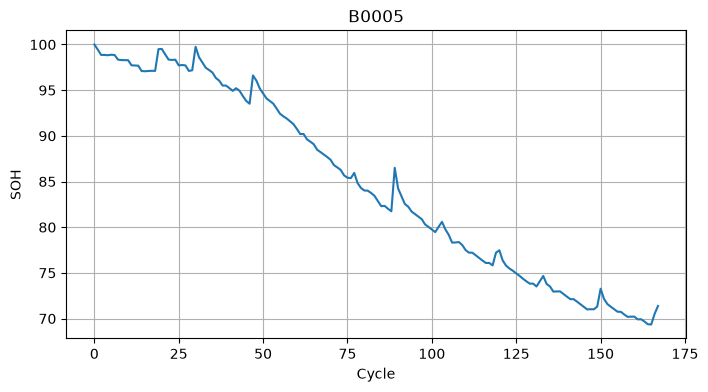

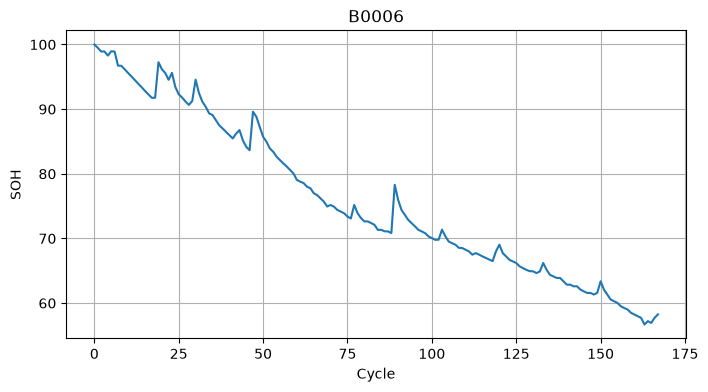

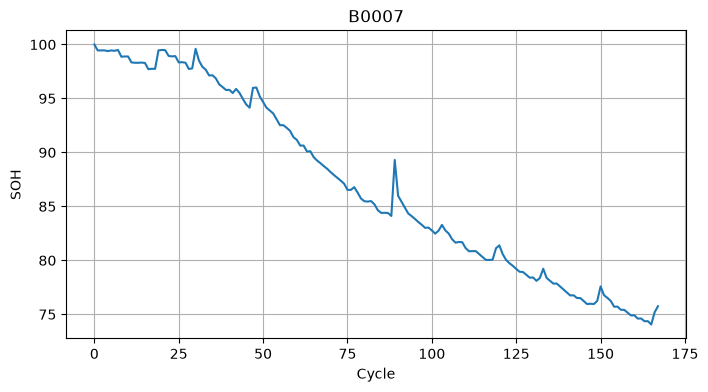

In [38]:
import matplotlib.pyplot as plt

for battery in ["B0005","B0006","B0007"]:

    temp = discharge_df[
        discharge_df["battery_id"]==battery
    ]

    plt.figure(figsize=(8,4))

    plt.plot(
        temp["cycle"],
        temp["SOH"]
    )

    plt.title(battery)
    plt.xlabel("Cycle")
    plt.ylabel("SOH")
    plt.grid(True)

    plt.show()

In [39]:
battery = discharge_df[
    discharge_df["battery_id"]=="B0005"
].copy()

battery = battery.sort_values("cycle")

battery[["cycle","SOH"]].head()

,cycle,SOH
5121,0,100.000000
5123,1,99.452721
5125,2,98.861386
5127,3,98.856718
5129,4,98.823482


In [40]:
from sklearn.linear_model import LinearRegression

X = battery[["cycle"]]
y = battery["SOH"]

model = LinearRegression()
model.fit(X,y)

print("Slope:",model.coef_[0])
print("Intercept:",model.intercept_)

Slope: -0.20827582482071652
Intercept: 102.09411347468321


In [41]:
import numpy as np

future_cycles = np.arange(
    0,
    250
).reshape(-1,1)

future_soh = model.predict(
    future_cycles
)

/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


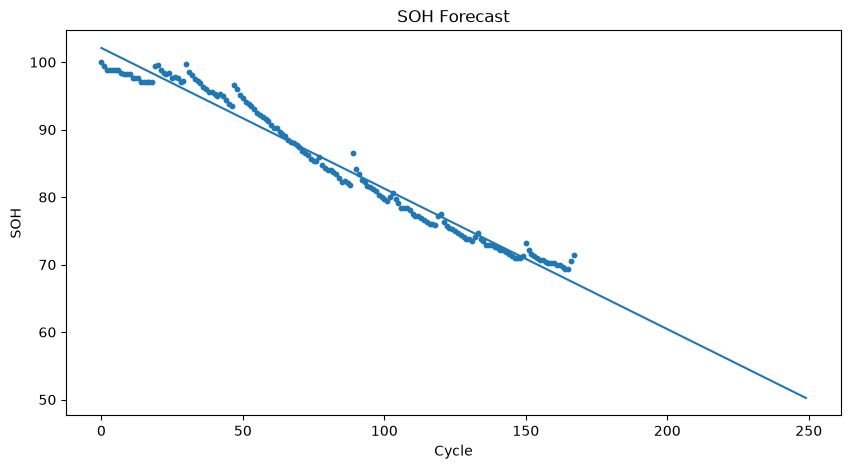

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    battery["cycle"],
    battery["SOH"],
    s=10
)

plt.plot(
    future_cycles,
    future_soh
)

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("SOH Forecast")

plt.show()

In [43]:
from sklearn.metrics import r2_score

pred = model.predict(X)

print("R2 =", r2_score(y, pred))


R2 = 0.9756281929050116


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = battery[["cycle"]]
y = battery["SOH"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Test R2 =", r2_score(y_test, pred))

Test R2 = 0.9761679755953839


In [45]:
discharge_df[
    ["battery_id","cycle","SOH"]
].head()

,battery_id,cycle,SOH
0,B0047,0,100.000000
4,B0047,1,91.044729
6,B0047,2,90.071793
8,B0047,3,88.607394
10,B0047,4,87.626770


In [46]:
model_df = discharge_df[
    ["battery_id","cycle","SOH"]
].copy()

model_df = model_df.dropna()

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

model_df["battery_code"] = le.fit_transform(
    model_df["battery_id"]
)

In [48]:
X = model_df[
    ["battery_code","cycle"]
]

y = model_df["SOH"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [51]:
from sklearn.metrics import r2_score

print(
    "R2 =",
    r2_score(y_test,pred)
)

R2 = 0.9160090772103042


In [52]:
discharge_df.groupby("battery_id")["SOH"].min()

battery_id
B0005    69.348842
B0006    56.689285
B0007    74.056928
B0018    72.293702
B0025    95.608686
B0026    76.317981
B0027    97.081395
B0028    95.149016
B0029    87.389752
B0030    87.720026
B0031    90.933115
B0032    86.366024
B0033    21.191206
B0034    40.978291
B0036    40.996604
B0038    50.270750
B0039    23.293742
B0040    24.554822
B0041    68.810533
B0042    77.244693
B0043    74.500705
B0044    74.035371
B0045    56.096042
B0046    65.020580
B0047    66.055917
B0048    69.824222
B0049    29.066502
B0050    21.729581
B0051    27.606542
B0052    60.682040
B0053    84.928192
B0054    63.429677
B0055    60.535233
B0056    58.412978
Name: SOH, dtype: float64

In [53]:
battery = discharge_df[
    discharge_df["battery_id"]=="B0005"
]

battery[
    battery["SOH"] <= 80
].head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle,nominal_capacity,SOH
5475,discharge,[2008. 5. 11. 21. 47. ...,24,B0005,355,5476,05476.csv,1.480414,NaN,NaN,100,1.856487,79.742726
5479,discharge,[2.0080e+03 5.0000e+00 1.2000e+01 2.0000e+00 3...,24,B0005,359,5480,05480.csv,1.475210,NaN,NaN,101,1.856487,79.462407
5490,discharge,[2008. 5. 12. 23. 53. ...,24,B0005,370,5491,05491.csv,1.480801,NaN,NaN,104,1.856487,79.763567
5494,discharge,[2008. 5. 13. 4. 35. ...,24,B0005,374,5495,05495.csv,1.469754,NaN,NaN,105,1.856487,79.168558
5498,discharge,[2008. 5. 13. 9. 24. ...,24,B0005,378,5499,05499.csv,1.453901,NaN,NaN,106,1.856487,78.314629


In [54]:
def get_rul_threshold(df, battery_id, threshold=80):

    battery = df[
        df["battery_id"] == battery_id
    ].sort_values("cycle")

    below = battery[
        battery["SOH"] <= threshold
    ]

    if len(below) == 0:
        return None

    return below.iloc[0]["cycle"]

print(
    get_rul_threshold(
        discharge_df,
        "B0005"
    )
)

100


In [55]:
results = []

for battery in discharge_df["battery_id"].unique():

    threshold_cycle = get_rul_threshold(
        discharge_df,
        battery
    )

    results.append(
        [battery, threshold_cycle]
    )

rul_df = pd.DataFrame(
    results,
    columns=[
        "battery_id",
        "cycle_at_80"
    ]
)

rul_df

,battery_id,cycle_at_80
0,B0047,17.0
1,B0045,3.0
2,B0048,21.0
3,B0046,17.0
4,B0043,103.0
5,B0032,NaN
6,B0039,1.0
7,B0040,0.0
8,B0029,NaN
9,B0028,NaN


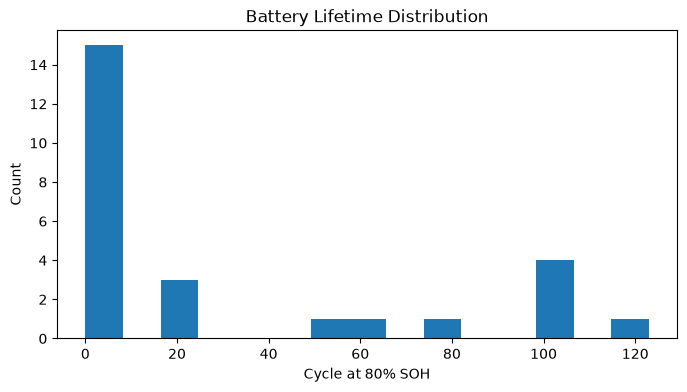

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    rul_df["cycle_at_80"].dropna(),
    bins=15
)

plt.xlabel("Cycle at 80% SOH")
plt.ylabel("Count")

plt.title(
    "Battery Lifetime Distribution"
)

plt.show()

In [57]:
rul_df.sort_values("cycle_at_80")

,battery_id,cycle_at_80
33,B0055,0.0
31,B0054,0.0
25,B0051,0.0
24,B0052,0.0
7,B0040,0.0
23,B0050,0.0
11,B0034,0.0
12,B0038,0.0
22,B0049,0.0
32,B0056,0.0


In [58]:
rul_df["cycle_at_80"].describe()

count     26.000000
mean      30.038462
std       42.962757
min        0.000000
25%        0.000000
50%        2.000000
75%       57.500000
max      123.000000
Name: cycle_at_80, dtype: float64

In [59]:
rul_df["cycle_at_80"].isna().sum()

np.int64(8)

In [60]:
model.predict([[180]])
model.predict([[200]])
model.predict([[250]])
model.predict([[300]])

/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([39.73981272])

In [61]:
for cycle in range(150,400):
    if model.predict([[cycle]])[0] < 80:
         print(cycle)
         break

150


/Users/mahmu/ev-digital-twin-mcp/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [62]:
import pandas as pd

model.predict(pd.DataFrame({"cycle": [180]}))
model.predict(pd.DataFrame({"cycle": [200]}))
model.predict(pd.DataFrame({"cycle": [250]}))
model.predict(pd.DataFrame({"cycle": [300]}))

array([39.73981272])

In [63]:
for c in [150, 180, 200, 250, 300]:
    pred_soh = model.predict(pd.DataFrame({"cycle": [c]}))[0]
    print(c, round(pred_soh, 2))

150 70.88
180 64.65
200 60.5
250 50.12
300 39.74


In [64]:
for c in range(0, 400):
    pred_soh = model.predict(pd.DataFrame({"cycle": [c]}))[0]
    if pred_soh < 80:
        print("Predicted cycle at 80% SOH:", c)
        break

Predicted cycle at 80% SOH: 107


In [65]:
for c in [100, 120, 150, 180, 200, 250, 300]:
    pred_soh = model.predict(pd.DataFrame({"cycle": [c]}))[0]
    print(c, round(pred_soh, 2))

100 81.25
120 77.1
150 70.88
180 64.65
200 60.5
250 50.12
300 39.74


In [66]:
def predict_future_soh(model, cycle):
    pred_soh = model.predict(
        pd.DataFrame({"cycle": [cycle]})
    )[0]
    return round(pred_soh, 2)


def estimate_cycle_at_threshold(model, threshold=80, max_cycle=500):
    for c in range(0, max_cycle + 1):
        pred_soh = model.predict(
            pd.DataFrame({"cycle": [c]})
        )[0]
        
        if pred_soh <= threshold:
            return c
    
    return None

In [67]:
print(predict_future_soh(model, 150))
print(estimate_cycle_at_threshold(model, threshold=80))

70.88
107


In [68]:
import joblib

joblib.dump(model, "../models/b0005_soh_model.pkl")

['../models/b0005_soh_model.pkl']

In [69]:
import os

os.path.exists("../models/b0005_soh_model.pkl")

True

In [70]:
discharge_df.groupby("battery_id").agg({
    "cycle":"max",
    "SOH":"min"
})

,cycle,SOH
battery_id,,
B0005,167,69.348842
B0006,167,56.689285
B0007,167,74.056928
B0018,131,72.293702
B0025,27,95.608686
B0026,27,76.317981
B0027,27,97.081395
B0028,27,95.149016
B0029,39,87.389752


<Axes: xlabel='cycle', ylabel='SOH'>

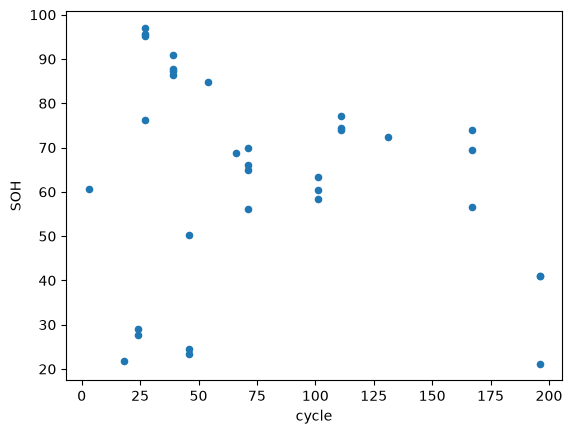

In [71]:
summary = discharge_df.groupby(
    "battery_id"
).agg({
    "cycle":"max",
    "SOH":"min"
})

summary.plot.scatter(
    x="cycle",
    y="SOH"
)

In [72]:
model_df.columns

Index(['battery_id', 'cycle', 'SOH', 'battery_code'], dtype='str')

In [73]:
discharge_df["ambient_temperature"].value_counts()

ambient_temperature
24    1367
4      803
43     160
22     120
44     105
Name: count, dtype: int64

In [74]:
discharge_df.groupby("battery_id")["ambient_temperature"].unique()

battery_id
B0005        [24]
B0006        [24]
B0007        [24]
B0018        [24]
B0025        [24]
B0026        [24]
B0027        [24]
B0028        [24]
B0029        [43]
B0030        [43]
B0031        [43]
B0032        [43]
B0033        [24]
B0034        [24]
B0036        [24]
B0038    [24, 44]
B0039    [24, 44]
B0040    [24, 44]
B0041         [4]
B0042     [22, 4]
B0043     [22, 4]
B0044     [22, 4]
B0045         [4]
B0046         [4]
B0047         [4]
B0048         [4]
B0049         [4]
B0050         [4]
B0051         [4]
B0052         [4]
B0053         [4]
B0054         [4]
B0055         [4]
B0056         [4]
Name: ambient_temperature, dtype: object

In [75]:
model_df = discharge_df[
    [
        "battery_id",
        "ambient_temperature",
        "cycle",
        "SOH"
    ]
].copy()

In [76]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

model_df["battery_code"] = (
    le.fit_transform(
        model_df["battery_id"]
    )
)

In [77]:
X = model_df[
    [
        "battery_code",
        "ambient_temperature",
        "cycle"
    ]
]

y = model_df["SOH"]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [80]:
from sklearn.metrics import r2_score

print(
    "R2:",
    r2_score(y_test, pred)
)

R2: 0.9130743993502026


In [81]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
)

,feature,importance
0,battery_code,0.583448
2,cycle,0.333396
1,ambient_temperature,0.083155


In [82]:
import joblib

joblib.dump(rf, "../models/battery_soh_rf_model.pkl")
joblib.dump(le, "../models/battery_label_encoder.pkl")

['../models/battery_label_encoder.pkl']

In [83]:
import os

print(os.path.exists("../models/battery_soh_rf_model.pkl"))
print(os.path.exists("../models/battery_label_encoder.pkl"))

True
True


In [84]:
from sklearn.linear_model import LinearRegression
import pandas as pd

slopes = []

for battery_id in discharge_df["battery_id"].unique():
    battery = discharge_df[
        discharge_df["battery_id"] == battery_id
    ].copy()

    if len(battery) < 10:
        continue

    X = battery[["cycle"]]
    y = battery["SOH"]

    model = LinearRegression()
    model.fit(X, y)

    slopes.append({
        "battery_id": battery_id,
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "min_cycle": battery["cycle"].min(),
        "max_cycle": battery["cycle"].max()
    })

slope_df = pd.DataFrame(slopes)
slope_df.head()

,battery_id,slope,intercept,min_cycle,max_cycle
0,B0047,-0.299810,85.520685,0,71
1,B0045,-0.328642,77.093891,0,71
2,B0048,-0.236566,86.672361,0,71
3,B0046,-0.314191,85.233475,0,71
4,B0043,-0.138330,95.571233,0,111


In [85]:
slope_df.to_csv("../models/battery_degradation_slopes.csv", index=False)

In [86]:
slope_df.sort_values("slope").head()

,battery_id,slope,intercept,min_cycle,max_cycle
22,B0049,-1.304852,55.806521,0,24
23,B0050,-1.101387,61.551995,0,18
24,B0051,-1.072588,52.168795,0,24
15,B0041,-1.057460,135.488355,42,66
1,B0045,-0.328642,77.093891,0,71


In [87]:
slope_df["degradation_speed"] = slope_df["slope"].abs()

slope_df.sort_values(
    "degradation_speed",
    ascending=False
).head(10)

,battery_id,slope,intercept,min_cycle,max_cycle,degradation_speed
6,B0039,1.436614,46.495379,1,46,1.436614
22,B0049,-1.304852,55.806521,0,24,1.304852
23,B0050,-1.101387,61.551995,0,18,1.101387
24,B0051,-1.072588,52.168795,0,24,1.072588
15,B0041,-1.057460,135.488355,42,66,1.057460
7,B0040,0.938478,60.201022,0,46,0.938478
12,B0038,0.903043,67.292136,0,46,0.903043
1,B0045,-0.328642,77.093891,0,71,0.328642
3,B0046,-0.314191,85.233475,0,71,0.314191
0,B0047,-0.299810,85.520685,0,71,0.299810


In [88]:
slope_df.sort_values(
    "degradation_speed",
    ascending=True
).head(10)

,battery_id,slope,intercept,min_cycle,max_cycle,degradation_speed
20,B0026,0.020982,97.482123,0,27,0.020982
18,B0036,-0.037973,73.255696,0,196,0.037973
11,B0034,-0.058233,81.854435,0,196,0.058233
16,B0027,-0.060273,99.803272,0,27,0.060273
31,B0056,-0.074297,91.303291,0,101,0.074297
13,B0033,-0.087025,85.239365,1,196,0.087025
29,B0053,-0.122566,94.256536,0,54,0.122566
32,B0055,-0.123381,87.399282,0,101,0.123381
19,B0025,-0.137464,100.099515,0,27,0.137464
4,B0043,-0.138330,95.571233,0,111,0.138330


In [89]:
slope_df.sort_values(
    "degradation_speed",
    ascending=False
).head(10)

,battery_id,slope,intercept,min_cycle,max_cycle,degradation_speed
6,B0039,1.436614,46.495379,1,46,1.436614
22,B0049,-1.304852,55.806521,0,24,1.304852
23,B0050,-1.101387,61.551995,0,18,1.101387
24,B0051,-1.072588,52.168795,0,24,1.072588
15,B0041,-1.057460,135.488355,42,66,1.057460
7,B0040,0.938478,60.201022,0,46,0.938478
12,B0038,0.903043,67.292136,0,46,0.903043
1,B0045,-0.328642,77.093891,0,71,0.328642
3,B0046,-0.314191,85.233475,0,71,0.314191
0,B0047,-0.299810,85.520685,0,71,0.299810


In [90]:
slope_df.sort_values(
    "degradation_speed",
    ascending=True
).head(10)

,battery_id,slope,intercept,min_cycle,max_cycle,degradation_speed
20,B0026,0.020982,97.482123,0,27,0.020982
18,B0036,-0.037973,73.255696,0,196,0.037973
11,B0034,-0.058233,81.854435,0,196,0.058233
16,B0027,-0.060273,99.803272,0,27,0.060273
31,B0056,-0.074297,91.303291,0,101,0.074297
13,B0033,-0.087025,85.239365,1,196,0.087025
29,B0053,-0.122566,94.256536,0,54,0.122566
32,B0055,-0.123381,87.399282,0,101,0.123381
19,B0025,-0.137464,100.099515,0,27,0.137464
4,B0043,-0.138330,95.571233,0,111,0.138330


In [91]:
clean_df = discharge_df.copy()

clean_df = clean_df.sort_values(
    ["battery_id", "cycle"]
)

In [92]:
clean_df["SOH_monotonic"] = (
    clean_df
    .groupby("battery_id")["SOH"]
    .cummin()
)

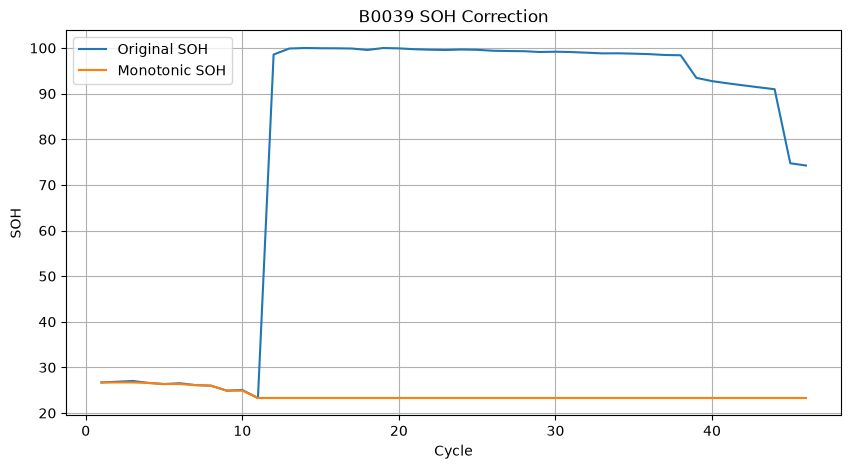

In [93]:
import matplotlib.pyplot as plt

battery_id = "B0039"

temp = clean_df[
    clean_df["battery_id"] == battery_id
]

plt.figure(figsize=(10,5))

plt.plot(
    temp["cycle"],
    temp["SOH"],
    label="Original SOH"
)

plt.plot(
    temp["cycle"],
    temp["SOH_monotonic"],
    label="Monotonic SOH"
)

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title(f"{battery_id} SOH Correction")
plt.legend()
plt.grid(True)

plt.show()

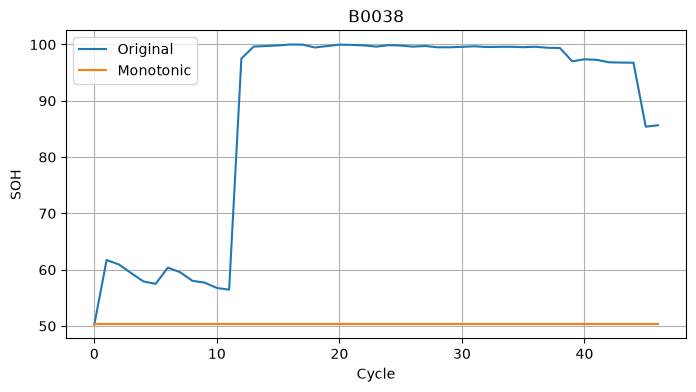

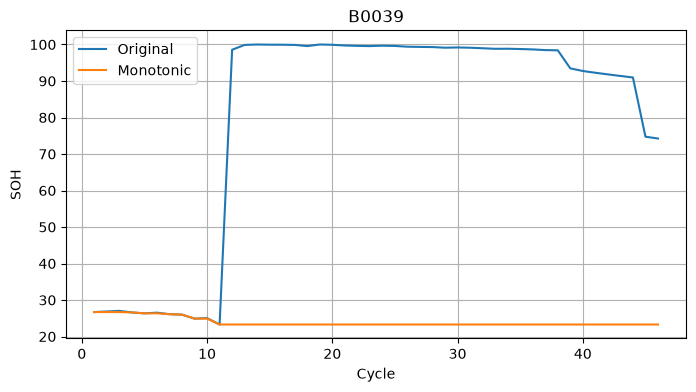

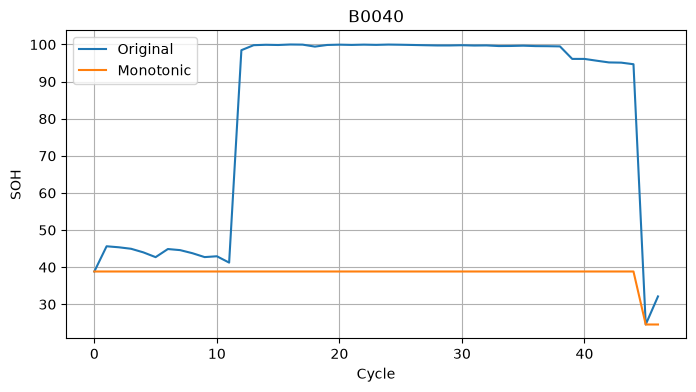

In [94]:
for battery_id in ["B0038", "B0039", "B0040"]:
    temp = clean_df[clean_df["battery_id"] == battery_id]

    plt.figure(figsize=(8,4))
    plt.plot(temp["cycle"], temp["SOH"], label="Original")
    plt.plot(temp["cycle"], temp["SOH_monotonic"], label="Monotonic")
    plt.title(battery_id)
    plt.xlabel("Cycle")
    plt.ylabel("SOH")
    plt.legend()
    plt.grid(True)
    plt.show()

In [95]:
from sklearn.linear_model import LinearRegression
import pandas as pd

slopes = []

for battery_id in clean_df["battery_id"].unique():

    battery = clean_df[
        clean_df["battery_id"] == battery_id
    ].copy()

    if len(battery) < 10:
        continue

    X = battery[["cycle"]]
    y = battery["SOH_monotonic"]

    model = LinearRegression()
    model.fit(X, y)

    slopes.append({
        "battery_id": battery_id,
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "min_cycle": battery["cycle"].min(),
        "max_cycle": battery["cycle"].max(),
        "start_soh": battery["SOH_monotonic"].iloc[0],
        "end_soh": battery["SOH_monotonic"].iloc[-1],
    })

slope_df_clean = pd.DataFrame(slopes)

slope_df_clean["degradation_speed"] = (
    slope_df_clean["slope"].abs()
)

slope_df_clean.sort_values("slope", ascending=False).head(10)

,battery_id,slope,intercept,min_cycle,max_cycle,start_soh,end_soh,degradation_speed
30,B0054,1.850027e-32,63.429677,0,101,63.429677,63.429677,1.850027e-32
14,B0036,6.047796e-33,40.996604,0,196,40.996604,40.996604,6.047796e-33
31,B0055,7.994161e-35,60.535233,0,101,60.535233,60.535233,7.994161e-35
10,B0031,0.000000e+00,90.933115,0,39,90.933115,90.933115,0.000000e+00
28,B0051,0.000000e+00,27.606542,0,24,27.606542,27.606542,0.000000e+00
32,B0056,-3.997081e-35,58.412978,0,101,58.412978,58.412978,3.997081e-35
13,B0034,-6.047796e-33,40.978291,0,196,40.978291,40.978291,6.047796e-33
15,B0038,-1.456581e-32,50.270750,0,46,50.270750,50.270750,1.456581e-32
16,B0039,-6.107859e-02,25.313209,1,46,26.698660,23.293742,6.107859e-02
11,B0032,-6.282609e-02,90.711962,0,39,90.012426,86.366024,6.282609e-02


In [96]:
slope_df_clean[
    slope_df_clean["slope"] > 0
]

,battery_id,slope,intercept,min_cycle,max_cycle,start_soh,end_soh,degradation_speed
14,B0036,6.047796e-33,40.996604,0,196,40.996604,40.996604,6.047796e-33
30,B0054,1.850027e-32,63.429677,0,101,63.429677,63.429677,1.850027e-32
31,B0055,7.994161e-35,60.535233,0,101,60.535233,60.535233,7.994161e-35


In [97]:
slope_df_clean["slope_corrected"] = slope_df_clean["slope"].apply(
    lambda x: min(x, 0)
)

slope_df_clean["degradation_speed"] = (
    slope_df_clean["slope_corrected"].abs()
)

In [98]:
slope_df_clean.to_csv(
    "../models/battery_degradation_slopes_clean.csv",
    index=False
)

In [99]:
latest_soh = (
    discharge_df
    .sort_values("cycle")
    .groupby("battery_id")
    .tail(1)
)

latest_soh[
    [
        "battery_id",
        "SOH",
        "ambient_temperature",
        "cycle"
    ]
].sort_values(
    "SOH",
    ascending=False
).head(10)

,battery_id,SOH,ambient_temperature,cycle
4156,B0026,97.370055,24,27
3235,B0027,97.081395,24,27
4076,B0025,95.608686,24,27
4388,B0052,95.294061,4,3
1526,B0028,95.149016,24,27
4252,B0031,90.967137,43,39
2991,B0030,87.720026,43,39
6805,B0053,87.539886,4,54
1445,B0029,87.389752,43,39
1104,B0032,86.366024,43,39


In [100]:
latest_soh[
    [
        "battery_id",
        "SOH",
        "ambient_temperature",
        "cycle"
    ]
].sort_values(
    "SOH",
    ascending=True
).head(10)

,battery_id,SOH,ambient_temperature,cycle
4314,B0049,29.066502,4,24
4500,B0051,29.081325,4,24
1350,B0040,32.119298,44,46
4362,B0050,44.662961,4,18
364,B0045,56.096042,4,71
5117,B0006,58.254475,24,167
3995,B0036,63.791862,24,196
732,B0046,66.761829,4,71
3156,B0041,68.810533,4,66
180,B0047,69.085915,4,71


In [101]:
fleet_df = latest_soh[
    [
        "battery_id",
        "SOH",
        "ambient_temperature",
        "cycle"
    ]
].copy()

fleet_df.to_csv(
    "../models/fleet_latest_status.csv",
    index=False
)

In [102]:
import os
os.path.exists("../models/fleet_latest_status.csv")

True